In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_enhancement_with_histogram(orig, enh, condition_title, title_orig="Original", title_enh="Enhanced"):
    plt.figure(figsize=(10, 7))

    plt.subplot(2, 2, 1)
    plt.imshow(orig, cmap='gray', vmin=0, vmax=255)
    plt.title(title_orig)
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(enh, cmap='gray', vmin=0, vmax=255)
    plt.title(title_enh)
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.hist(orig.ravel(), bins=256, range=[0, 256], color='black', histtype='bar', rwidth=0.8)
    plt.title(f"Histogram - {title_orig}")
    plt.xlim([0, 256])

    plt.subplot(2, 2, 4)
    plt.hist(enh.ravel(), bins=256, range=[0, 256], color='black', histtype='bar', rwidth=0.8)
    plt.title(f"Histogram - {title_enh}")
    plt.xlim([0, 256])

    plt.suptitle(condition_title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [40]:
def manual_histogram_equalization(img):
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[img]

def manual_log_transform(img):
    img_float = img.astype(np.float64)
    c = 255 / np.log(1 + np.max(img_float))
    log_img = c * (np.log(1 + img_float))
    return np.clip(log_img, 0, 255).astype(np.uint8)

def manual_gamma_correction(img, gamma=1.0):
    table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(img, table)

def manual_contrast_stretching(img):
    r_min, r_max = np.min(img), np.max(img)
    stretched = ((img - r_min) / (r_max - r_min)) * 255.0
    return np.clip(stretched, 0, 255).astype(np.uint8)

def manual_negative(img):
    return 255 - img

def manual_median_filter(img, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            output[i, j] = np.median(window)
    return output.astype(np.uint8)

def manual_gaussian_blur(img):
    kernel = np.array([[1, 2, 1],
                       [2, 4, 2],
                       [1, 2, 1]], dtype=np.float32) / 16.0
    return cv2.filter2D(img, -1, kernel)

def manual_laplacian_sharpening(img):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]], dtype=np.float32)
    return cv2.filter2D(img, -1, kernel)

def manual_unsharp_masking(img, k=1.0):
    blur = cv2.GaussianBlur(img, (5, 5), 2.0)
    mask = img.astype(np.float64) - blur.astype(np.float64)
    sharpened = img.astype(np.float64) + k * mask
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def manual_frequency_lpf(img, radius=30):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
    mask_area = x*x + y*y <= radius*radius
    mask[mask_area] = 1
    fshift = dft_shift * mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    return np.clip(np.abs(img_back), 0, 255).astype(np.uint8)

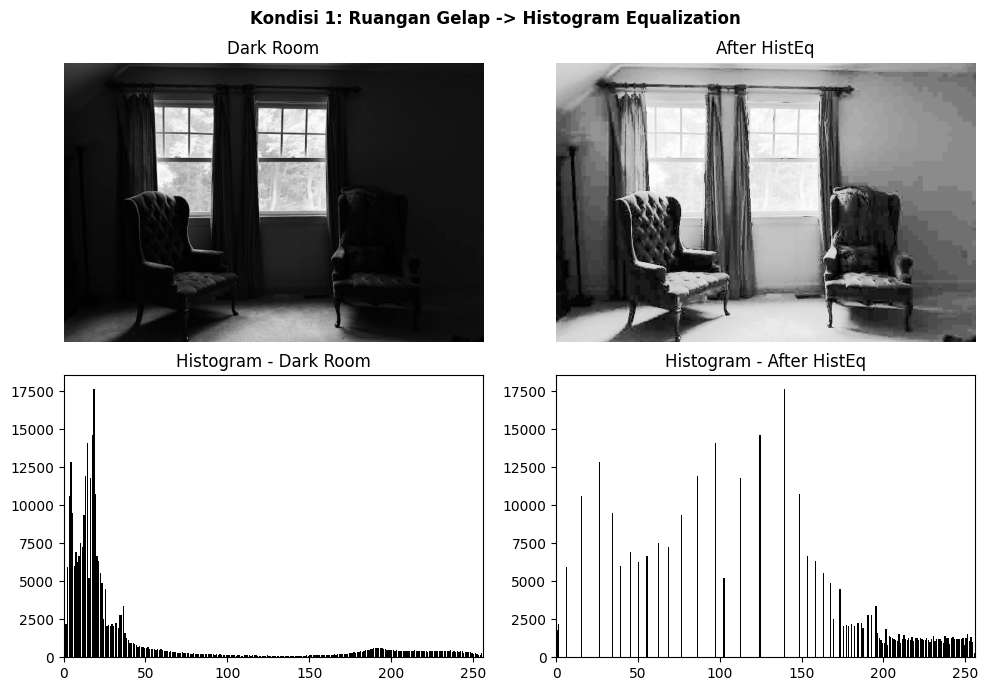

In [29]:
img1 = cv2.imread('1.jpg', cv2.IMREAD_GRAYSCALE)
if img1 is not None:
    res1 = manual_histogram_equalization(img1)
    plot_enhancement_with_histogram(img1, res1, "Kondisi 1: Ruangan Gelap -> Histogram Equalization", "Dark Room", "After HistEq")

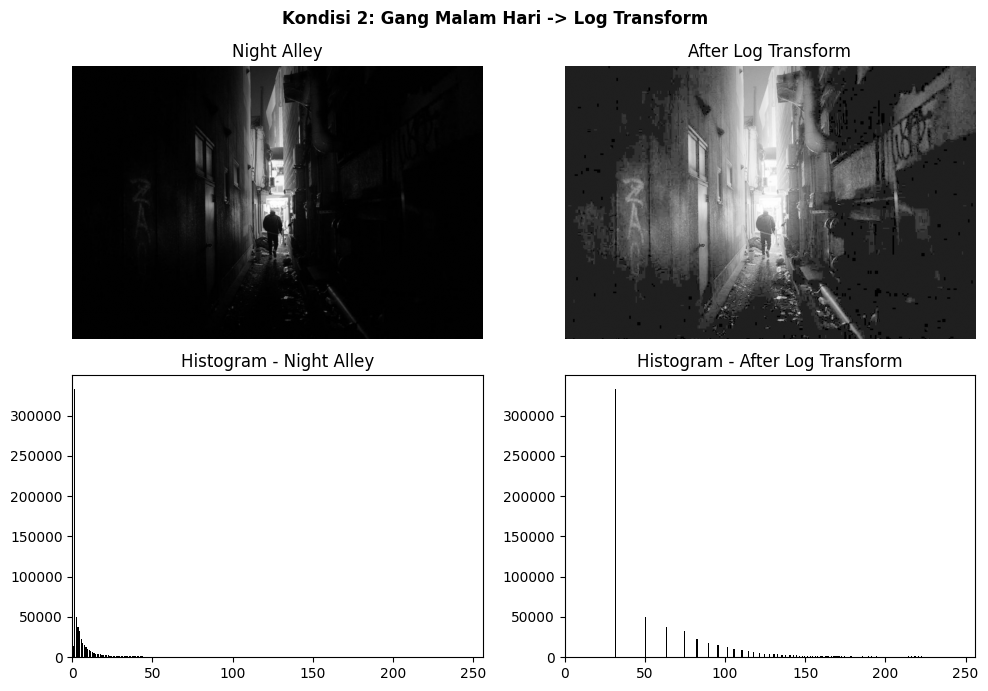

In [30]:
img2 = cv2.imread('2.jpg', cv2.IMREAD_GRAYSCALE)
if img2 is not None:
    res2 = manual_log_transform(img2)
    plot_enhancement_with_histogram(img2, res2, "Kondisi 2: Gang Malam Hari -> Log Transform", "Night Alley", "After Log Transform")

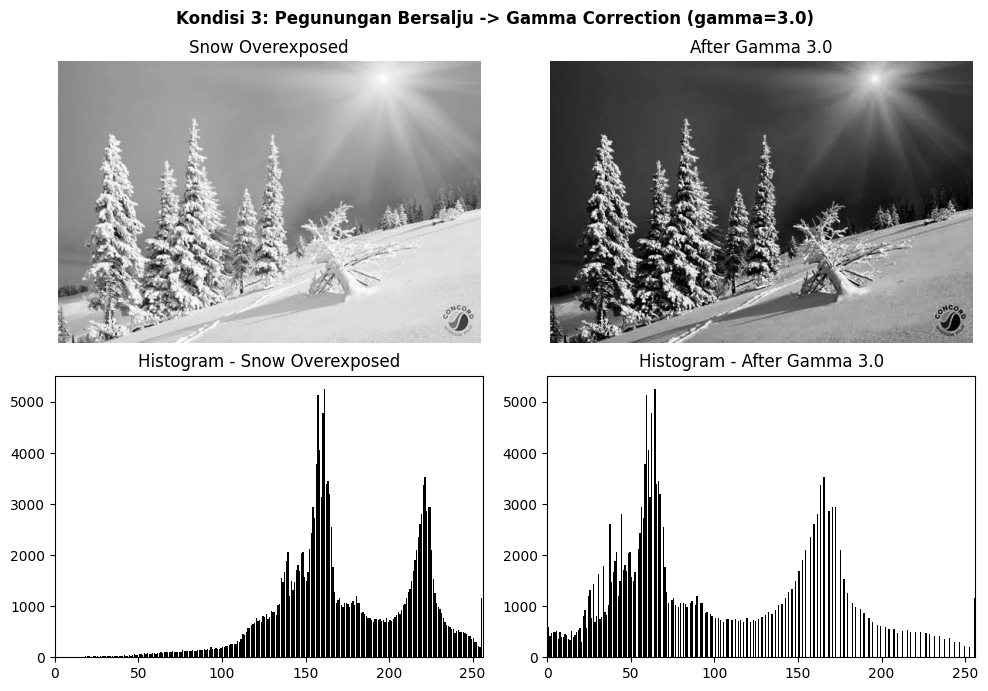

In [31]:
img3 = cv2.imread('3.jpg', cv2.IMREAD_GRAYSCALE)
if img3 is not None:
    res3 = manual_gamma_correction(img3, gamma=3.0)
    plot_enhancement_with_histogram(img3, res3, "Kondisi 3: Pegunungan Bersalju -> Gamma Correction (gamma=3.0)", "Snow Overexposed", "After Gamma 3.0")


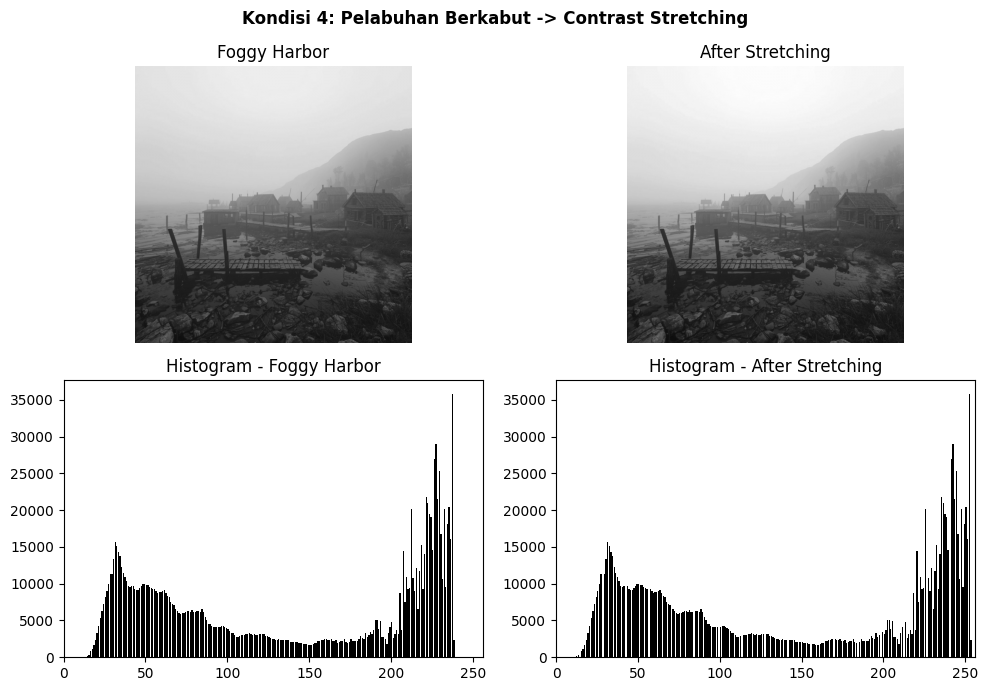

In [32]:
img4 = cv2.imread('4.jpg', cv2.IMREAD_GRAYSCALE)
if img4 is not None:
    res4 = manual_contrast_stretching(img4)
    plot_enhancement_with_histogram(img4, res4, "Kondisi 4: Pelabuhan Berkabut -> Contrast Stretching", "Foggy Harbor", "After Stretching")

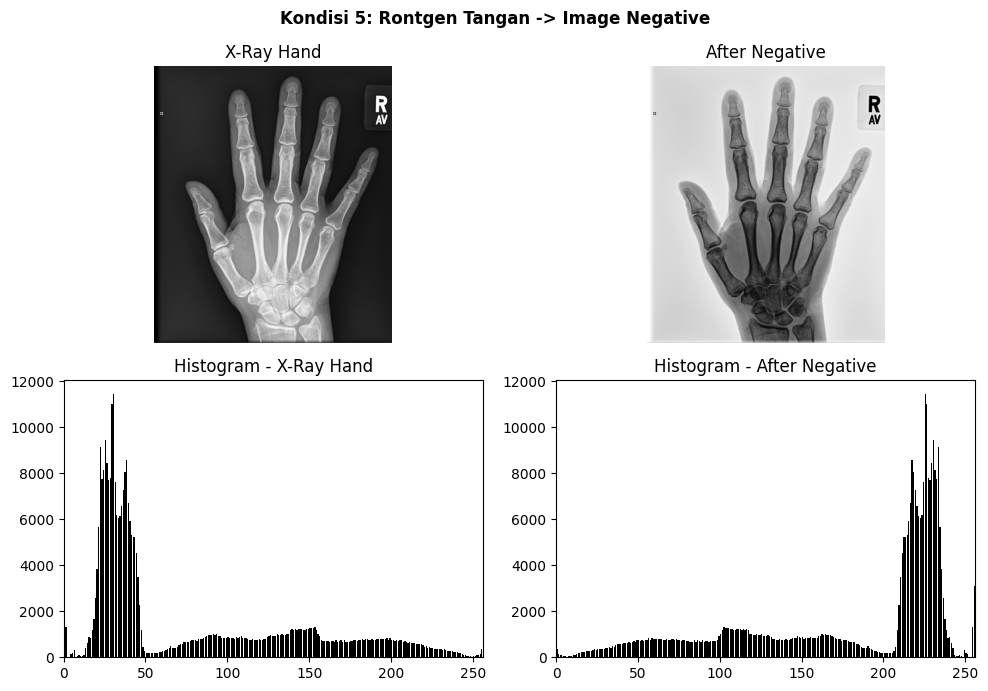

In [33]:
img5 = cv2.imread('5.jpeg', cv2.IMREAD_GRAYSCALE)
if img5 is not None:
    res5 = manual_negative(img5)
    plot_enhancement_with_histogram(img5, res5, "Kondisi 5: Rontgen Tangan -> Image Negative", "X-Ray Hand", "After Negative")

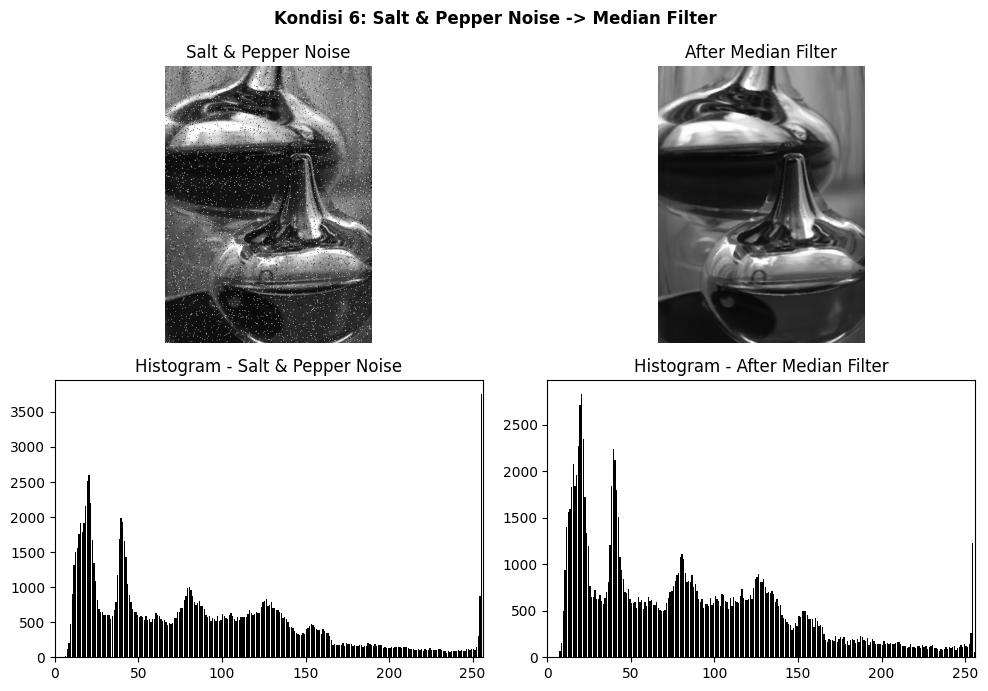

In [34]:
img6 = cv2.imread('6.png', cv2.IMREAD_GRAYSCALE)
if img6 is not None:
    res6 = manual_median_filter(img6, kernel_size=3)
    plot_enhancement_with_histogram(img6, res6, "Kondisi 6: Salt & Pepper Noise -> Median Filter", "Salt & Pepper Noise", "After Median Filter")

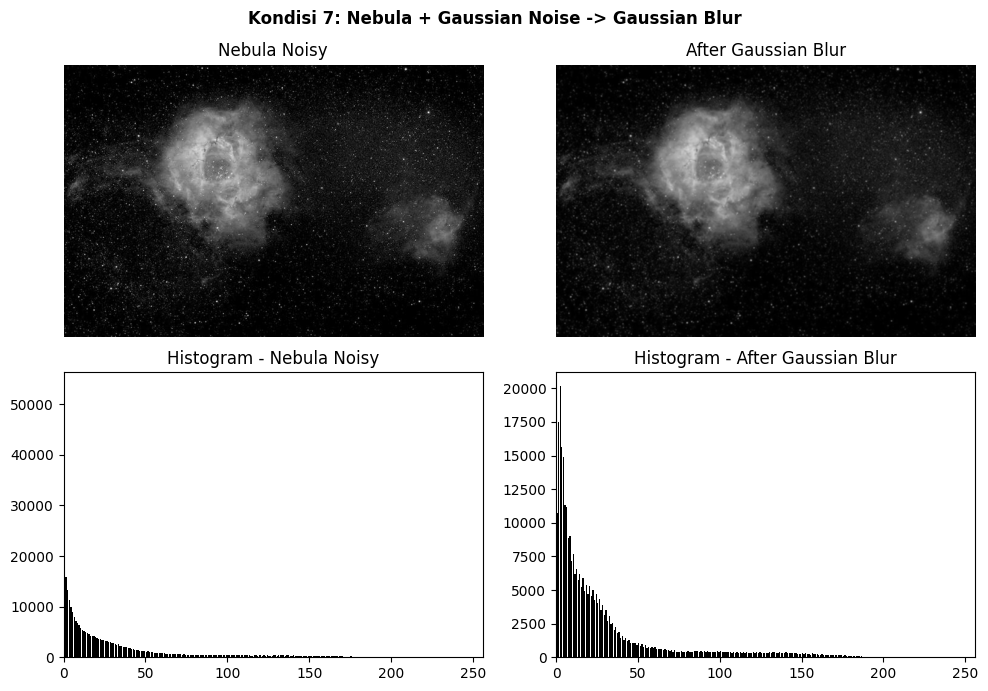

In [35]:
img7 = cv2.imread('7.jpg', cv2.IMREAD_GRAYSCALE)
if img7 is not None:
    res7 = manual_gaussian_blur(img7)
    plot_enhancement_with_histogram(img7, res7, "Kondisi 7: Nebula + Gaussian Noise -> Gaussian Blur", "Nebula Noisy", "After Gaussian Blur")

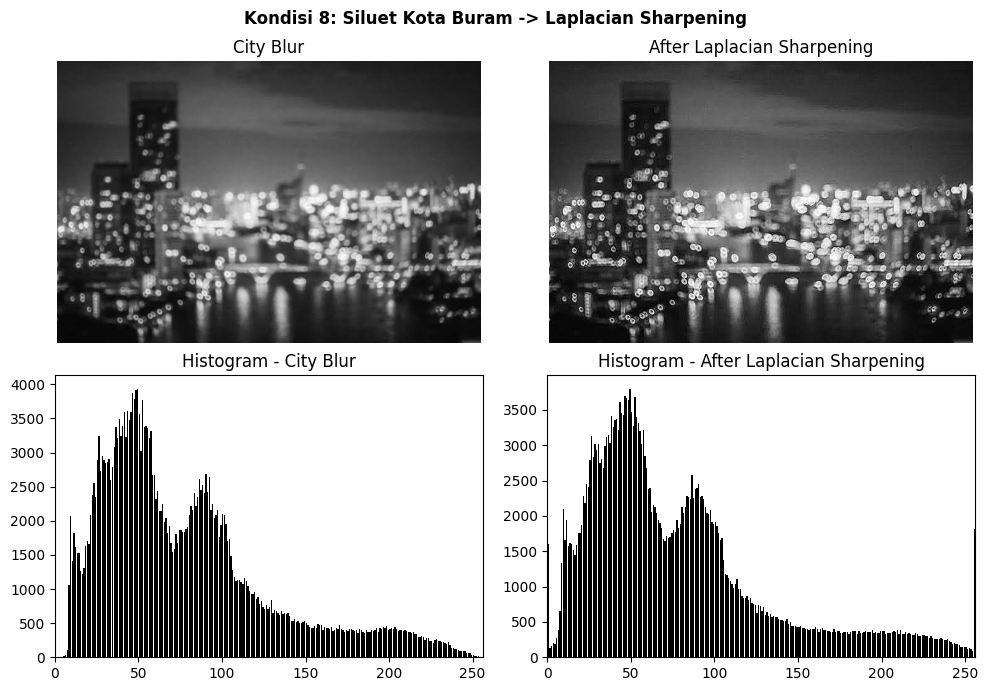

In [36]:
img8 = cv2.imread('8.jpg', cv2.IMREAD_GRAYSCALE)
if img8 is not None:
    res8 = manual_laplacian_sharpening(img8)
    plot_enhancement_with_histogram(img8, res8, "Kondisi 8: Siluet Kota Buram -> Laplacian Sharpening", "City Blur", "After Laplacian Sharpening")

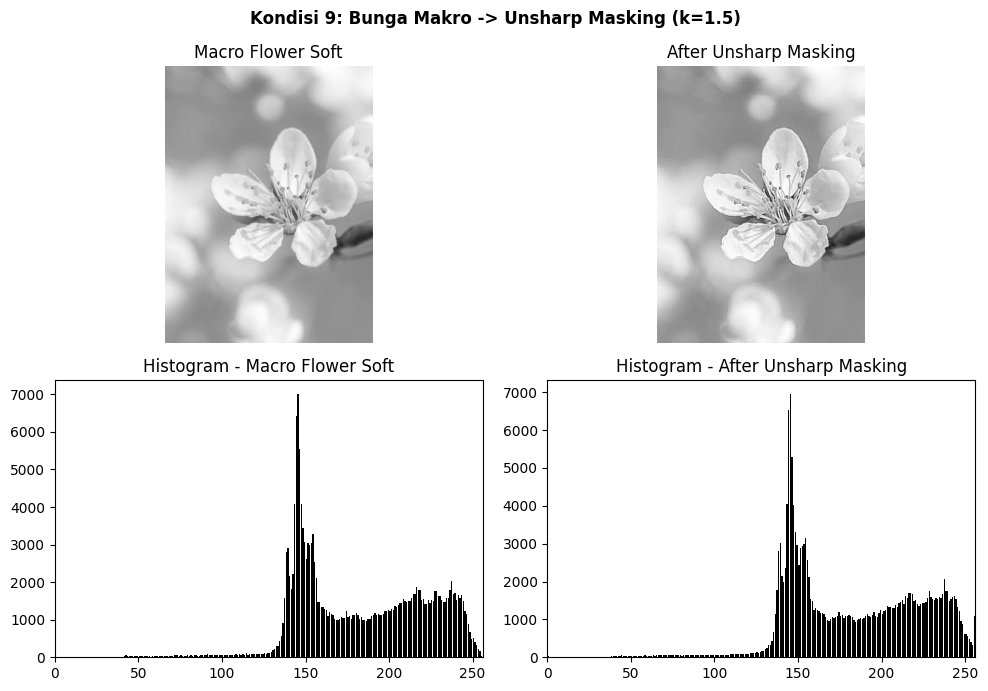

In [37]:
img9 = cv2.imread('9.jpg', cv2.IMREAD_GRAYSCALE)
if img9 is not None:
    res9 = manual_unsharp_masking(img9, k=1.5)
    plot_enhancement_with_histogram(img9, res9, "Kondisi 9: Bunga Makro -> Unsharp Masking (k=1.5)", "Macro Flower Soft", "After Unsharp Masking")

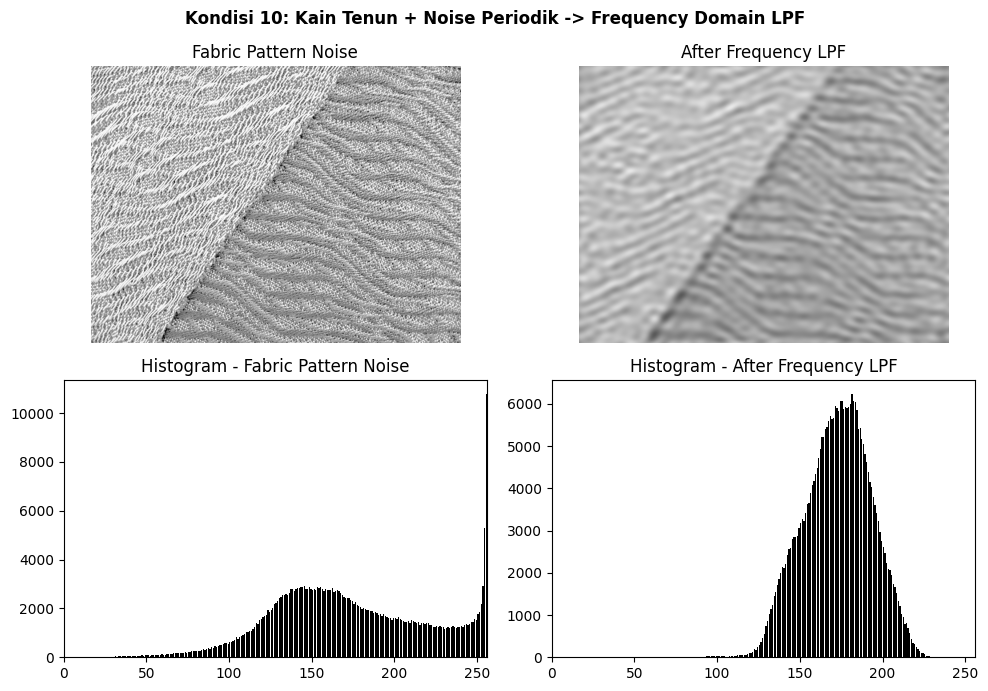

In [38]:
img10 = cv2.imread('10.jpg', cv2.IMREAD_GRAYSCALE)
if img10 is not None:
    res10 = manual_frequency_lpf(img10, radius=30)
    plot_enhancement_with_histogram(img10, res10, "Kondisi 10: Kain Tenun + Noise Periodik -> Frequency Domain LPF", "Fabric Pattern Noise", "After Frequency LPF")

# LAPORAN ANALISIS TUGAS PENGOLAHAN CITRA DIGITAL: IMAGE ENHANCEMENT

Nama  : Farhan Rizky Alkarim

NIM   : 25/568476/PA/23997

## 1. Ringkasan Eksekutif & Tabel Pemetaan Metode

Laporan ini menyajikan analisis mengenai penerapan teknik Peningkatan Kualitas Citra (*Image Enhancement*) menggunakan Python dan OpenCV. Pengujian dilakukan pada 10 kondisi citra yang merepresentasikan tiga kategori utama pengolahan citra digital: **Transformasi Intensitas & Kontras Spasial**, **Penapisan Spasial (Smoothing & Sharpening)**, serta **Penapisan Domain Frekuensi**.

| No | Kondisi Citra Input | Masalah Utama Citra | Metode Solusi | Formula / Kernel / Parameter Utama | Dampak Perubahan Citra & Histogram |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | Ruangan Gelap | *Underexposed* & Kontras Rendah | Histogram Equalization | $s_k = T(r_k) = (L-1) \sum_{j=0}^{k} p_r(r_j)$ | Meratakan akumulasi piksel; detail tersembunyi di area gelap muncul kembali. |
| **2** | Gang Malam Hari | *Dynamic Range* Ekstrem (Sangat Gelap + Cahaya Lampu) | Logarithmic Transformation | $s = c \cdot \log(1 + r)$ | Meregangkan nilai piksel gelap tanpa merusak area terang (*non-linear expansion*). |
| **3** | Pegunungan Bersalju | *Overexposed* / Terlalu Terang | Gamma Correction | $s = c \cdot r^\gamma \quad (\gamma = 3.0)$ | Menurunkan nilai kecerahan tinggi secara signifikan, mengembalikan detail tekstur salju. |
| **4** | Pelabuhan Berkabut | Kontras Rendah / Pudar (*Low Contrast*) | Contrast Stretching | $s = \frac{r - r_{\min}}{r_{\max} - r_{\min}} \cdot 255$ | Meregangkan rentang piksel yang sempit ke batas penuh $[0, 255]$. |
| **5** | Rontgen Tangan (X-Ray) | Latar Belakang Dominan Terang | Image Negative | $s = (L - 1) - r = 255 - r$ | Membalikkan tingkat keabuan; struktur tulang/jaringan medis menjadi lebih kontras. |
| **6** | Kendi | Salt & Pepper Noise (Bintik Hitam-Putih) | Median Filter | Jendela Non-Linier ($3 \times 3$) | Mengeliminasi piksel ekstrem (0 dan 255) tanpa mengaburkan garis batas objek (*edge*). |
| **7** | Luar Angkasa / Nebula | Gaussian Noise (Noise Kontinu/Berbintik) | Gaussian Blur | Kernel $3 \times 3$ berbobot Gaussian ($\sigma$ terdistribusi) | Menghaluskan variasi piksel acak dengan konvolusi terbobot. |
| **8** | Siluet Kota Buram | *Out of Focus* / Tepi Kabur | Laplacian Sharpening | Kernel $\begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$ | Mengamplify turunan kedua intensitas; mempertajam garis tepi arsitektur gedung. |
| **9** | Bunga Makro | *Soft Focus* / Kurang Detail Halus | Unsharp Masking | $I_{\text{sharp}} = I + k \cdot (I - I_{\text{blur}}) \quad (k = 1.5)$ | Memperkuat kontras lokal pada garis tepi tanpa memunculkan *artifact noise* berlebih. |
| **10**| Kain Tenun | Noise Periodik / Interferensi Pola | Frequency Domain Low-Pass Filter | $H(u,v) = 1 \text{ jika } D(u,v) \le D_0 \text{ else } 0$ | Mengisolasi dan memotong frekuensi tinggi pada domain Fourier, menghilangkan noise pola. |

---

## 2. Analisis Detail Setiap Kondisi Citra

### Kondisi 1: Potret Ruangan Gelap $\rightarrow$ Histogram Equalization

* **Deskripsi Masalah:** Citra ruangan gelap memiliki distribusi nilai piksel yang menumpuk di area *shadow* (skala $0 - 50$). Hal ini menyebabkan detail objek seperti furnitur dan jendela tersembunyi dalam area gelap.
* **Mekanisme Algoritma:** Algoritma meratakan fungsi distribusi kumulatif (*Cumulative Distribution Function* / CDF) dari nilai intensitas citra. Nilai CDF yang diskrit dipetakan ulang secara terdistribusi penuh dari skala $0$ hingga $255$.
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Objek dalam ruangan yang semula tidak terlihat menjadi sangat jelas. Apabila citra awal terlalu gelap pekat, dapat muncul fenomena *posterization* (efek batas piksel bertingkat) karena rincian warna asli terbatas.
  * **Perubahan Histogram:** Puncak histogram yang semula terkonsentrasi rapat di sisi kiri ($0$) merenggang dan tersebar merata sepanjang sumbu horizontal ($0 - 255$).

---

### Kondisi 2: Gang Malam Hari $\rightarrow$ Logarithmic Transformation

* **Deskripsi Masalah:** Citra memiliki perbedaan intensitas ekstrem antara sudut gang yang pekat gelap dan titik lampu jalan yang sangat terang.
* **Mekanisme Algoritma:** Transfomasi logaritma bekerja dengan fungsi kurva non-linier $s = c \cdot \log(1 + r)$. Fungsi ini meregangkan nilai piksel gelap (skala rendah) secara eksponensial sambil menekan (*compress*) peningkatan nilai piksel terang (skala tinggi).
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Detail tekstur dinding dan jalanan gang yang gelap menjadi terang dan dapat diidentifikasi, sementara area di sekitar lampu tetap terjaga tanpa mengalami *over-saturation*.
  * **Perubahan Histogram:** Distribusi piksel dari rentang nilai rendah dipindahkan secara drastis ke arah tengah (rentang menengah), memperluas variasi intensitas pada area bayangan.

---

### Kondisi 3: Pegunungan Bersalju $\rightarrow$ Gamma Correction ($\gamma = 3.0$)

* **Deskripsi Masalah:** Citra mengalami pemaparan cahaya berlebih (*overexposed*), sehingga bukit salju tampak dominan putih polos dan kehilangan detail kontur/lipatan es.
* **Mekanisme Algoritma:** Koreksi Gamma menggunakan persamaan $s = c \cdot r^\gamma$. Ketika nilai $\gamma > 1.0$, kurva transformasi melengkung ke bawah, yang secara matematis menekan piksel berintensitas tinggi (*highlight*) menjadi lebih gelap secara proporsional.
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Silau pada area salju berkurang secara signifikan, sehingga tekstur, bayangan celah gunung, dan kontur es terlihat dengan tingkat kontras yang pas.
  * **Perubahan Histogram:** Seluruh puncak histogram yang menumpuk rapat di sumbu paling kanan ($200 - 255$) terdorong kembali ke arah tengah ($100 - 180$).

---

### Kondisi 4: Pelabuhan Berkabut $\rightarrow$ Contrast Stretching

* **Deskripsi Masalah:** Partikel kabut memantulkan cahaya secara acak, mengakibatkan rentang nilai piksel citra sangat sempit (misalnya hanya berada pada skala $80 - 160$). Citra terlihat abu-abu dan pudar.
* **Mekanisme Algoritma:** Contrast stretching melakukan pemetaan linier dengan meregangkan rentang intensitas awal $[r_{\min}, r_{\max}]$ agar memenuhi seluruh rentang dinamis yang tersedia $[0, 255]$.
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Pelabuhan dan kapal yang semula samar terlihat jauh lebih tegas, hitam menjadi lebih pekat dan area terang menjadi lebih jelas.
  * **Perubahan Histogram:** Bentuk pola dasar histogram tidak berubah, namun jarak antar baris histogram merenggang memenuhi seluruh domain $0 - 255$.

---

### Kondisi 5: Rontgen Tangan (X-Ray) $\rightarrow$ Image Negative

* **Deskripsi Masalah:** Pada citra hasil pemindaian radiologi X-Ray standar, struktur tulang yang padat tampak berwarna terang/putih sedangkan latar belakang jaringan lunak tampak gelap. Untuk analisis medis tertentu, pembalikan visual diperlukan untuk menegaskan batas jaringan.
* **Mekanisme Algoritma:** Transformasi negatif membalikkan nilai intensitas piksel dengan rumus $s = (L - 1) - r$. Nilai piksel $0$ berubah menjadi $255$, dan sebaliknya.
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Latar belakang menjadi putih terang dan struktur tulang berubah menjadi gelap, memudahkan isolasi visual terhadap retakan kecil atau keanehan pada jaringan.
  * **Perubahan Histogram:** Histogram citra hasil merupakan cerminan simetris sempurna (*horizontal flip*) dari histogram citra asli terhadap titik tengah $127.5$.

---

### Kondisi 6: Keranjang Buah + Salt & Pepper Noise $\rightarrow$ Median Filter

* **Deskripsi Masalah:** Citra terkontaminasi oleh gangguan impulsif berupa bintik-bintik acak berwarna hitam ($0$) dan putih ($255$) akibat kesalahan transmisi sensor.
* **Mekanisme Algoritma:** Median filter adalah penapis non-linier yang menggeser jendela matriks (misal $3 \times 3$) di atas citra, mengurutkan seluruh nilai piksel di dalam jendela tersebut, lalu mengganti piksel pusat dengan nilai tengah (*median*).
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Bintik noise impulsif hilang sepenuhnya tanpa membuat garis tepi buah menjadi buram (*blur*), mempertahankan ketajaman objek.
  * **Perubahan Histogram:** Puncak ekstrem yang semula muncul di titik $0$ dan $255$ pada histogram terhapus dan terdistribusi kembali ke rentang nilai riil objek.

---

### Kondisi 7: Nebula + Gaussian Noise $\rightarrow$ Gaussian Blur

* **Deskripsi Masalah:** Citra astronomi luar angkasa terganggu oleh *Gaussian Noise* (variasi intensitas acak dengan distribusi normal) yang disebabkan oleh *thermal noise* pada sensor kamera.
* **Mekanisme Algoritma:** Menggunakan fungsi konvolusi matriks kernel spasial di mana bobot nilai ditentukan oleh distribusi Gaussian 2D. Piksel tetangga yang lebih dekat ke pusat memiliki bobot pengaruh lebih tinggi dibanding piksel yang lebih jauh.
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Bintik-bintik halus tereliminasi sehingga tampilan nebula menjadi lebih halus (*smooth*) dan transisi warna antarbintang tampak menyatu secara alami.
  * **Perubahan Histogram:** Fluktuasi tajam/gerigi pada histogram menjadi lebih rata dan kurva histogram terlihat lebih mulus.

---

### Kondisi 8: Siluet Kota Buram $\rightarrow$ Laplacian Sharpening

* **Deskripsi Masalah:** Citra bangunan kota mengalami kehilangan ketajaman (*out of focus*), menyebabkan batas-batas garis arsitektur gedung menjadi kabur (*blur*).
* **Mekanisme Algoritma:** Operator Laplacian memanfaatkan turunan kedua dari fungsi intensitas spasial ($\nabla^2 f$) untuk mendeteksi area perubahan intensitas yang cepat (tepi objek). Kernel dipadukan langsung dengan citra asli untuk menambah magnitudo perbedaan tepi.
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Garis tepi gedung, jendela, dan struktur arsitektur tampak jauh lebih tegas dan tajam.
  * **Perubahan Histogram:** Rentang nilai piksel mengalami perluasan pada batas-batas ekstrem sebagai akibat peningkatan penyimpangan nilai pada tepi objek.

---

### Kondisi 9: Bunga Makro $\rightarrow$ Unsharp Masking ($k = 1.5$)

* **Deskripsi Masalah:** Foto jarak dekat (*macro*) pada mahkota bunga memiliki fokus yang terlalu lembut (*soft focus*), sehingga tekstur serat kelopak bunga tampak kurang menonjol.
* **Mekanisme Algoritma:** Algoritma membuat salinan citra yang kabur (*blurred image*), memutuskannya dari citra asli untuk menghasilkan matriks *edge mask* ($g_{\text{mask}} = f - f_{\text{blur}}$), lalu menambahkan *mask* tersebut kembali ke citra asli dengan faktor pengali $k$.
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Tekstur halus serat kelopak bunga dan benang sari menjadi sangat jelas tanpa menimbulkan efek *noise halo* berlebihan pada latar belakang.
  * **Perubahan Histogram:** Terjadi pergeseran minor pada magnitudo frekuensi piksel lokal, di mana perbedaan nilai piksel tetangga diperbesar.

---

### Kondisi 10: Kain Tenun + Noise Periodik $\rightarrow$ Frequency Domain Low-Pass Filter (FFT LPF)

* **Deskripsi Masalah:** Citra pola kain tenun terganggu oleh pola garisan berulang (*moire/periodic noise*) akibat interferensi gelombang saat proses pemindaian (*scanning*).
* **Mekanisme Algoritma:** Citra mentah ditransformasikan dari domain spasial ke domain frekuensi menggunakan *Fast Fourier Transform* 2D (2D-FFT). Filter LPF berbentuk lingkaran dengan radius $R=30$ diterapkan untuk menahan (*attenuate*) komponen frekuensi tinggi luar (lokasi noise berulang) dan mempertahankan frekuensi rendah di pusat. Citra kemudian dikembalikan ke domain spasial via Inverse FFT (IFFT).
* **Analisis Citra & Histogram:**
  * **Visual Citra:** Pola garis interferensi periodik yang mengganggu hilang secara signifikan, menyisakan struktur dasar tekstur kain.
  * **Perubahan Histogram:** Komponen nilai piksel yang teratur akibat garis frekuensi tinggi terdistribusi ulang menjadi lebih homogen.

---

## 3. Kesimpulan Teknis

Penggunaan teknik pengolahan citra digital harus disesuaikan secara presisi dengan karakteristik kerusakan (*degradation*) yang dialami oleh citra input:

1. **Manipulasi Intensitas Spasial** (Histogram Equalization, Log, Gamma, Contrast Stretching, Negative) sangat efektif untuk menyelesaikan masalah pencahayaan, pencucian warna, dan kontras tanpa mengubah struktur geometris piksel.
2. **Penapisan Spasial** memiliki domain aplikasi yang spesifik: *Median Filter* unggul mutlak untuk *Salt & Pepper noise*, sedangkan *Gaussian Blur* lebih optimal untuk *Gaussian noise*. Penajaman dengan *Laplacian* dan *Unsharp Masking* efektif mengembalikan detail tepi yang hilang.
3. **Penapisan Domain Frekuensi** (FFT) merupakan metode terkuat untuk mengatasi gangguan berulang (*periodic noise*) atau interferensi gelombang yang sulit diisolasi jika hanya menggunakan konvolusi spasial biasa.